In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

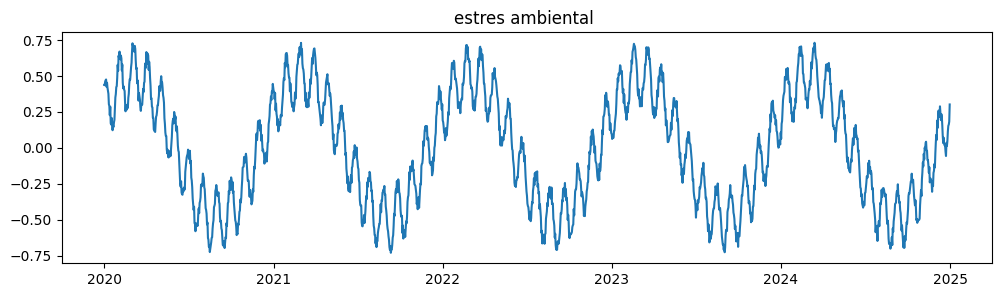

In [19]:
FECHA_INICIO = '2020-01-01'
FECHA_FIN = '2024-12-31'  # 5 años, para que la red vea varios ciclos anuales completos
fechas = pd.date_range(FECHA_INICIO, FECHA_FIN, freq='D')  # 1 muestra por dia
n_dias = len(fechas)

t = np.arange(n_dias)
offset1, offset2 = np.random.rand(2)
,
#     cambiamos freq1/freq2 fijas por periodo anual (365d) y mensual (30d) en vez de aleatorias por muestra
estres = 0.5 * np.sin(2*np.pi*(t/365 - offset1))
estres += 0.2 * np.sin(2*np.pi*(t/30 - offset2))
estres += 0.1 * (np.random.rand(n_dias) - 0.5)

plt.figure(figsize=(12, 3))
plt.plot(fechas, estres)
plt.title('estres ambiental ')
plt.show()

In [3]:
def param(base, sensibilidad, ruido_std, minimo=0):
    ruido = ruido_std * np.random.randn(n_dias)
    return np.clip(base + sensibilidad * estres + ruido, minimo, None)

ph          = np.clip(7.75 - 0.9*estres + 0.15*np.random.randn(n_dias), 5.5, 10)
turbidez    = param(base=2.0,   sensibilidad=4.0,   ruido_std=0.4)
solidos     = param(base=55,    sensibilidad=35,    ruido_std=4)
color       = param(base=7,     sensibilidad=9,     ruido_std=1.2)
nitratos    = param(base=18,    sensibilidad=22,    ruido_std=2.5)
arsenico    = param(base=0.004, sensibilidad=0.007, ruido_std=0.0008)
plomo       = param(base=0.003, sensibilidad=0.008, ruido_std=0.0008)
ecoli       = param(base=0.2,   sensibilidad=1.2*(estres>0), ruido_std=0.15)

df = pd.DataFrame({'fecha': fechas, 'ph': ph, 'turbidez': turbidez, 'solidos': solidos,
                    'color': color, 'nitratos': nitratos, 'arsenico': arsenico,
                    'plomo': plomo, 'ecoli': ecoli}).set_index('fecha')
df.head()

,ph,turbidez,solidos,color,nitratos,arsenico,plomo,ecoli
fecha,,,,,,,,
2020-01-01,8.211725,1.019336,46.106922,2.276517,5.984855,0.002422,0.001084,0.000000
2020-01-02,8.246242,1.255052,47.104286,4.766450,14.523043,0.000634,0.001299,0.203315
2020-01-03,8.102835,0.473971,46.854909,3.782531,10.486888,0.001277,0.000214,0.014147
2020-01-04,8.059897,1.503345,46.422975,3.360746,11.605142,0.002548,0.001152,0.000000
2020-01-05,7.837793,1.734582,43.834220,4.860806,10.049123,0.002481,0.000329,0.219428


es un dataframe de 1825 dias con 8 parametros

count    1827.000000
mean        6.399308
std         1.826977
min         2.048222
25%         4.920543
50%         6.806768
75%         8.019024
max         9.318944
Name: wqi, dtype: float64


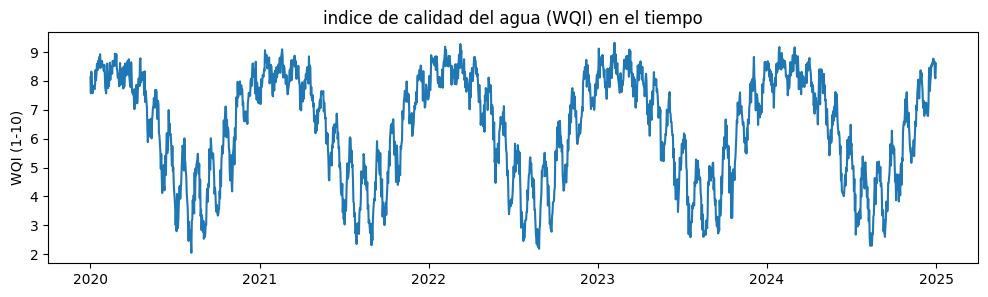

In [4]:
def subscore_menor_igual(valor, limite):
    return np.clip(1 - valor/limite, 0, 1)

sub_ph       = np.clip(1 - np.abs(df['ph'] - 7.75)/1.25, 0, 1)
sub_turbidez = subscore_menor_igual(df['turbidez'], 5)
sub_solidos  = subscore_menor_igual(df['solidos'], 100)
sub_color    = subscore_menor_igual(df['color'], 15)
sub_nitratos = subscore_menor_igual(df['nitratos'], 45)
sub_arsenico = subscore_menor_igual(df['arsenico'], 0.01)
sub_plomo    = subscore_menor_igual(df['plomo'], 0.01)
sub_ecoli    = subscore_menor_igual(df['ecoli'], 1)

subscores = np.stack([sub_ph, sub_turbidez, sub_solidos, sub_color, sub_nitratos, sub_arsenico, sub_plomo, sub_ecoli], axis=1)
df['wqi'] = 1 + 9 * subscores.mean(axis=1)

print(df['wqi'].describe())
plt.figure(figsize=(12, 3))
plt.plot(df.index, df['wqi'])
plt.title('indice de calidad del agua (WQI) en el tiempo')
plt.ylabel('WQI (1-10)')
plt.show()

calculo el índice WQI del 1 al 10 como el promedio de 8 sub-puntajes, uno por cada parámetro




cada parámetro se puntúa de 0 a 1 según qué tan lejos esté del límite aceptable.

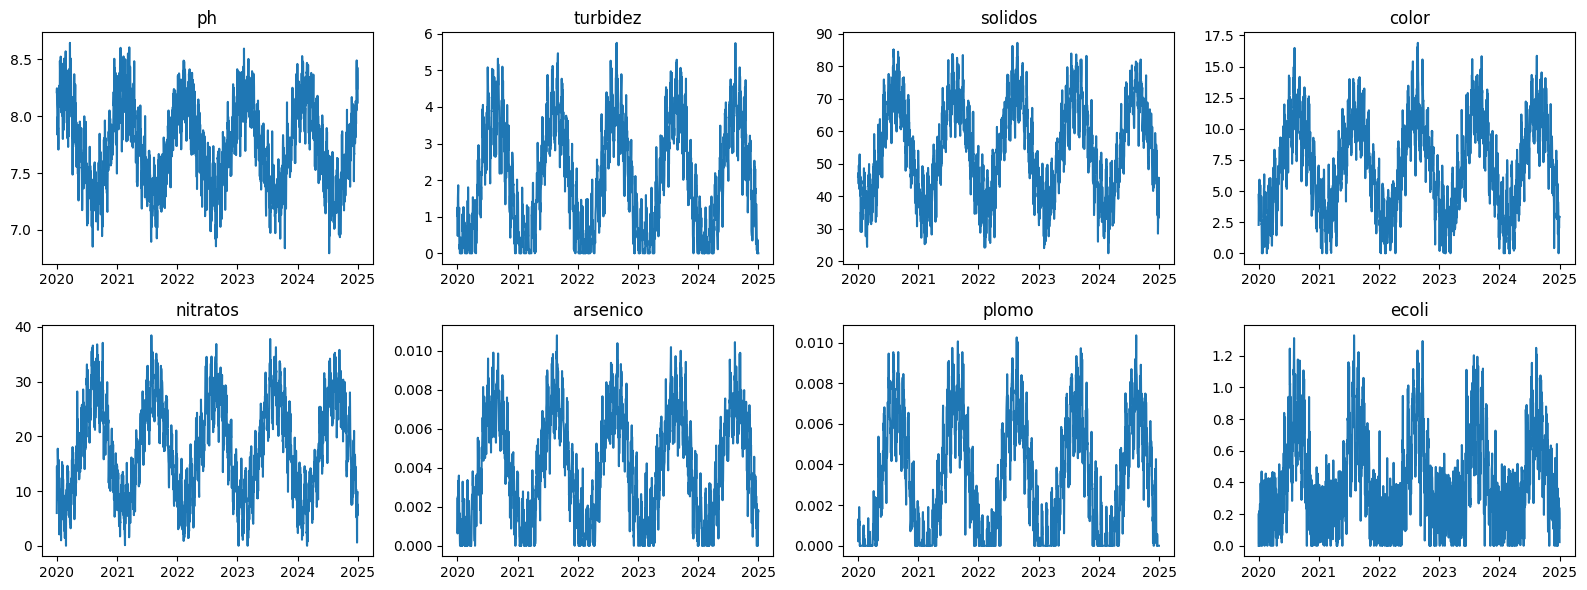

In [5]:
fig, axs = plt.subplots(2, 4, figsize=(16, 6))
for ax, col in zip(axs.flat, ['ph', 'turbidez', 'solidos', 'color', 'nitratos', 'arsenico', 'plomo', 'ecoli']):
    ax.plot(df.index, df[col])
    ax.set_title(col)
plt.tight_layout()
plt.show()

### Split, normalización y ventaneo
A partir de acá reusamos exactamente el mismo patrón que ya veníamos usando en los cuadernillos de RNN (split cronológico, normalización solo con train, ventaneo).

In [6]:
serie = df['wqi'].values.astype(np.float32)
n = len(serie)
n_train = int(n * 0.70)
n_val = int(n * 0.15)

train_raw = serie[:n_train]
val_raw = serie[n_train:n_train+n_val]
test_raw = serie[n_train+n_val:]

wqi_min, wqi_max = train_raw.min(), train_raw.max()
def normalizar(x): return (x - wqi_min) / (wqi_max - wqi_min)
def desnormalizar(x): return x * (wqi_max - wqi_min) + wqi_min

train_norm = normalizar(train_raw)
val_norm = normalizar(val_raw)
test_norm = normalizar(test_raw)
len(train_norm), len(val_norm), len(test_norm)

(1278, 274, 275)

 divido los datos en tres conjuntos: 70% para entrenar, 15% para validar durante el entrenamiento, y 15% para prueba final Después normalizo todos entre 0 y 1 usando solo el mínimo y máximo del conjunto de entrenamiento, para que no se filtre información de validación o test hacia el entrenamiento. El resultado: 1278 días para entrenar, 274 para validar, 275 para probar."

In [7]:
n_steps = 90  # 3 meses de contexto

def hacer_ventanas(s, n_steps):
    X, y = [], []
    for i in range(len(s) - n_steps):
        X.append(s[i:i+n_steps])
        y.append(s[i+n_steps])
    return np.array(X, dtype=np.float32)[..., np.newaxis], np.array(y, dtype=np.float32)[..., np.newaxis]

X_train, y_train = hacer_ventanas(train_norm, n_steps)
X_valid, y_valid = hacer_ventanas(val_norm, n_steps)
X_test, y_test = hacer_ventanas(test_norm, n_steps)
X_train.shape, y_train.shape

((1188, 90, 1), (1188, 1))

 le doy a la red 90 días seguidos de historial , y tiene que predecir el día 91. La ventana se desliza día a día — cada ventana es una muestra de entrenamiento. Resultado: 1188 muestras, cada una con 90 días de entrada y 1 día a predecir

In [8]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, ix):
        return self.X[ix], self.y[ix]

dataset = {'train': TimeSeriesDataset(X_train, y_train), 'eval': TimeSeriesDataset(X_valid, y_valid), 'test': TimeSeriesDataset(X_test, y_test)}
dataloader = {k: DataLoader(v, batch_size=64, shuffle=(k=='train')) for k, v in dataset.items()}
len(dataset['train']), len(dataset['eval']), len(dataset['test'])

(1188, 184, 185)

una clase que envuelve las muestras de entrada y salida. Después creo los DataLoaders, que cargan los datos en batches de 64 muestras por vez. Solo(mezclo) el conjunto de entrenamiento; validación y test van en orden. El resultado: 1188 batches para entrenar, 184 para validar, 185 para probar."

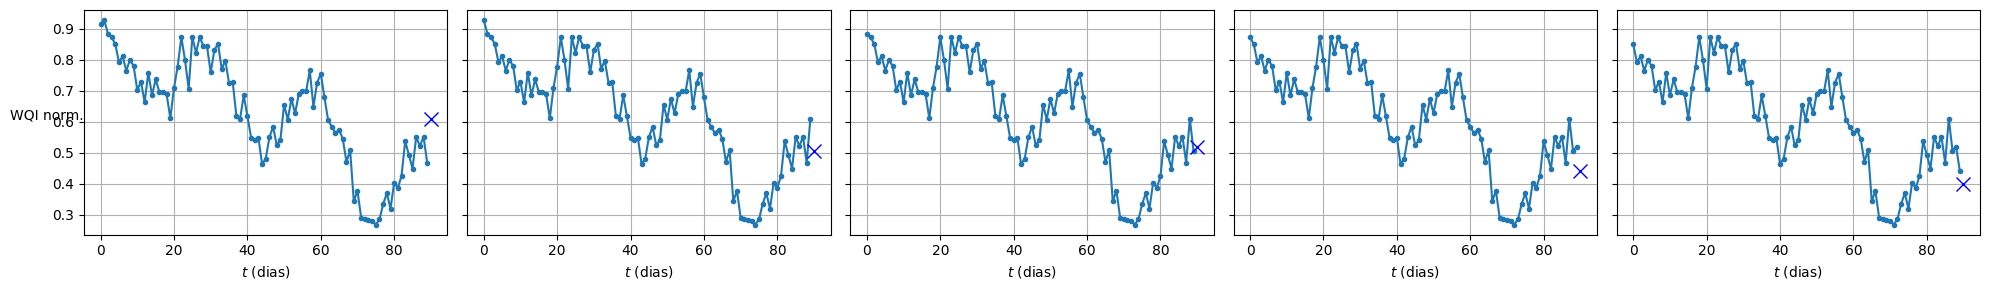

In [9]:
def plot_series(series, y=None, y_pred=None, x_label="$t$ (dias)", y_label="WQI norm.", n=5):
    fig, axes = plt.subplots(1, n, sharey=True, figsize=(4*n, 3))
    for col in range(n):
        ax = axes[col]
        ax.plot(series[col, :, 0], ".-")
        if y is not None:
            ax.plot(len(series[col]), y[col], "bx", markersize=10)
        if y_pred is not None:
            ax.plot(len(series[col]), y_pred[col], "ro")
        ax.grid(True)
        if col == 0:
            ax.set_ylabel(y_label, rotation=0)
        ax.set_xlabel(x_label)
    plt.tight_layout()
    plt.show()

plot_series(X_test, y_test)

"Acá visualizo 5 muestras aleatorias del conjunto de test. En cada gráfico ves 90 días de historial (línea azul con puntos) y una equis azul al final que marca el valor real del día 91 que la red tiene que predecir. Eso es lo que verás después cuando la red haga predicciones: compararás la equis azul (real) contra un círculo rojo (predicción) en el mismo punto."

In [10]:
class RNNModel(torch.nn.Module):
    def __init__(self, hidden_size=20, num_layers=2, dropout=0):
        super().__init__()
        self.rnn = torch.nn.RNN(input_size=1, hidden_size=hidden_size, num_layers=num_layers, batch_first=True, dropout=dropout)
        self.fc = torch.nn.Linear(hidden_size, 1)
    def forward(self, x):
        x, h = self.rnn(x)
        return self.fc(x[:, -1])

class LSTMModel(RNNModel):
    def __init__(self, hidden_size=20, num_layers=2, dropout=0):
        super().__init__(hidden_size, num_layers, dropout)
        self.rnn = torch.nn.LSTM(input_size=1, hidden_size=hidden_size, num_layers=num_layers, batch_first=True, dropout=dropout)

class GRUModel(RNNModel):
    def __init__(self, hidden_size=20, num_layers=2, dropout=0):
        super().__init__(hidden_size, num_layers, dropout)
        self.rnn = torch.nn.GRU(input_size=1, hidden_size=hidden_size, num_layers=num_layers, batch_first=True, dropout=dropout)

In [11]:
def fit(model, dataloader, epochs=60, lr=1e-3, weight_decay=0.0, ckpt_path='model.pt', patience=5, verbose=True):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = torch.nn.MSELoss()
    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    epochs_sin_mejora = 0
    bar = tqdm(range(1, epochs+1)) if verbose else range(1, epochs+1)
    for epoch in bar:
        model.train()
        train_loss = []
        for X, y in dataloader['train']:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X), y)
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())
        model.eval()
        val_loss = []
        with torch.no_grad():
            for X, y in dataloader['eval']:
                X, y = X.to(device), y.to(device)
                val_loss.append(criterion(model(X), y).item())
        history['train_loss'].append(np.mean(train_loss))
        history['val_loss'].append(np.mean(val_loss))
        if verbose:
            bar.set_description(f"loss {history['train_loss'][-1]:.5f} val_loss {history['val_loss'][-1]:.5f}")
        if history['val_loss'][-1] < best_val_loss:
            best_val_loss = history['val_loss'][-1]
            epochs_sin_mejora = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            epochs_sin_mejora += 1
            if epochs_sin_mejora >= patience:
                if verbose:
                    print(f'early stopping en epoca {epoch}')
                break
    return history

def predict(model, dataloader):
    model.eval()
    preds = []
    with torch.no_grad():
        for X, y in dataloader:
            preds.append(model(X.to(device)).cpu())
    return torch.cat(preds)

### Búsqueda de hiperparámetros (subconjunto) y entrenamiento de las 3 redes

In [12]:
candidatos = [{'hidden_size': 16, 'lr': 1e-2}, {'hidden_size': 20, 'lr': 1e-3}, {'hidden_size': 32, 'lr': 1e-3}, {'hidden_size': 32, 'lr': 1e-4}]
resultados = []
for c in candidatos:
    torch.manual_seed(SEED)
    m = RNNModel(hidden_size=c['hidden_size'])
    h = fit(m, dataloader, epochs=8, lr=c['lr'], ckpt_path='tmp.pt', patience=99, verbose=False)
    resultados.append({**c, 'val_loss': h['val_loss'][-1]})
    print(c, '->', h['val_loss'][-1])
mejor = min(resultados, key=lambda r: r['val_loss'])
mejor

{'hidden_size': 16, 'lr': 0.01} -> 0.002899988399197658
{'hidden_size': 20, 'lr': 0.001} -> 0.005039239612718423
{'hidden_size': 32, 'lr': 0.001} -> 0.003526689950376749
{'hidden_size': 32, 'lr': 0.0001} -> 0.03929192883272966


{'hidden_size': 16, 'lr': 0.01, 'val_loss': np.float64(0.002899988399197658)}

In [13]:
torch.manual_seed(SEED)
rnn_model = RNNModel(hidden_size=mejor['hidden_size'], dropout=0.2)
hist_rnn = fit(rnn_model, dataloader, lr=mejor['lr'], weight_decay=1e-5, ckpt_path='rnn.pt')

  0%|          | 0/60 [00:00<?, ?it/s]

early stopping en epoca 21


In [14]:
torch.manual_seed(SEED)
lstm_model = LSTMModel(hidden_size=mejor['hidden_size'], dropout=0.2)
hist_lstm = fit(lstm_model, dataloader, lr=mejor['lr'], weight_decay=1e-5, ckpt_path='lstm.pt')

  0%|          | 0/60 [00:00<?, ?it/s]

early stopping en epoca 29


In [15]:
torch.manual_seed(SEED)
gru_model = GRUModel(hidden_size=mejor['hidden_size'], dropout=0.2)
hist_gru = fit(gru_model, dataloader, lr=mejor['lr'], weight_decay=1e-5, ckpt_path='gru.pt')

  0%|          | 0/60 [00:00<?, ?it/s]

early stopping en epoca 51


In [16]:
def evaluar(model, ckpt_path):
    model.load_state_dict(torch.load(ckpt_path))
    model.to(device)
    y_pred = predict(model, dataloader['test']).numpy()
    mse = float(np.mean((y_pred - y_test)**2))
    mae = float(np.mean(np.abs(y_pred - y_test)))
    return mse, mae, y_pred

mse_rnn, mae_rnn, pred_rnn = evaluar(rnn_model, 'rnn.pt')
mse_lstm, mae_lstm, pred_lstm = evaluar(lstm_model, 'lstm.pt')
mse_gru, mae_gru, pred_gru = evaluar(gru_model, 'gru.pt')

tabla = pd.DataFrame([
    {'Modelo': 'RNN', 'Test MSE': mse_rnn, 'Test MAE': mae_rnn},
    {'Modelo': 'LSTM', 'Test MSE': mse_lstm, 'Test MAE': mae_lstm},
    {'Modelo': 'GRU', 'Test MSE': mse_gru, 'Test MAE': mae_gru},
]).sort_values('Test MSE')
tabla

,Modelo,Test MSE,Test MAE
2,GRU,0.003014,0.043963
1,LSTM,0.003249,0.045769
0,RNN,0.003757,0.049365


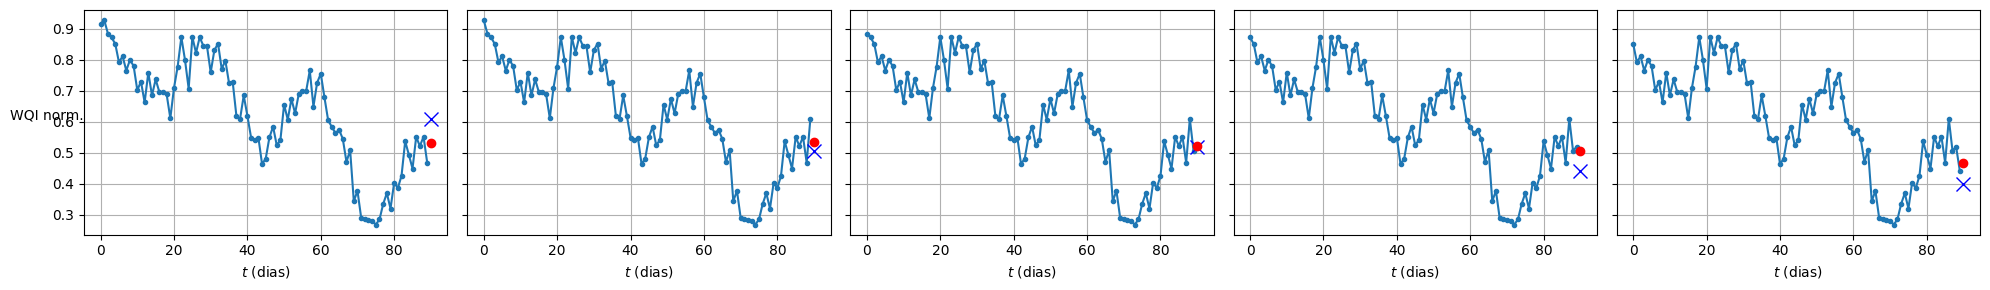

In [17]:
plot_series(X_test, y_test, pred_gru)

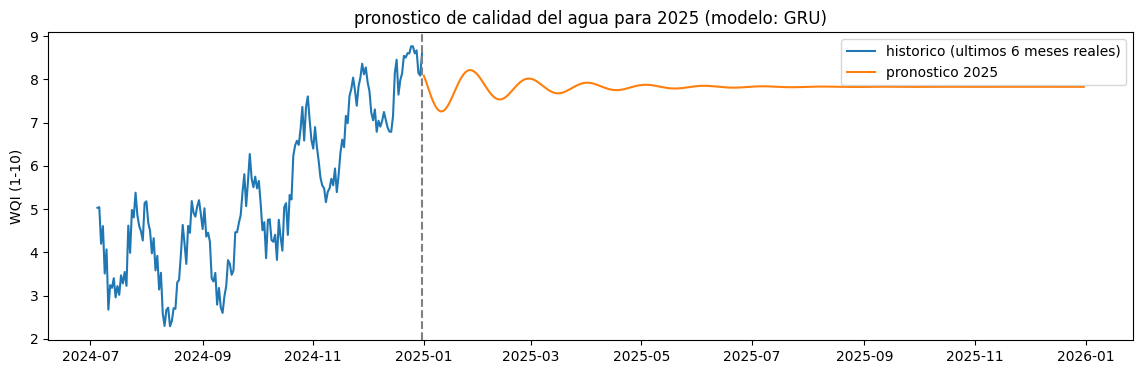

In [18]:
mejor_modelo = {'RNN': rnn_model, 'LSTM': lstm_model, 'GRU': gru_model}[tabla.iloc[0]['Modelo']]
mejor_modelo.eval()

ventana = test_norm[-n_steps:].copy()
predicciones_2025 = []
with torch.no_grad():
    for _ in range(365):
        x = torch.from_numpy(ventana[-n_steps:].astype(np.float32)).view(1, n_steps, 1).to(device)
        pred = mejor_modelo(x).cpu().item()
        predicciones_2025.append(pred)
        ventana = np.append(ventana, pred)

fechas_2025 = pd.date_range('2025-01-01', '2025-12-31', freq='D')
wqi_2025 = desnormalizar(np.array(predicciones_2025))

plt.figure(figsize=(14, 4))
plt.plot(df.index[-180:], df['wqi'].values[-180:], label='historico (ultimos 6 meses reales)')
plt.plot(fechas_2025, wqi_2025, label='pronostico 2025')
plt.axvline(df.index[-1], color='gray', linestyle='--')
plt.ylabel('WQI (1-10)')
plt.legend()
plt.title(f'pronostico de calidad del agua para 2025 (modelo: {tabla.iloc[0]["Modelo"]})')
plt.show()

"Acá tomo el mejor modelo y lo uso iterativamente para predecir todo el año 2025: predice un día, ese valor predicho entra como entrada para predecir el siguiente, y así 365 veces. En el gráfico ves los últimos 6 meses reales de 2024 en azul, y el pronóstico para 2025 en naranja. Nota importante: como cada predicción se basa en la anterior, el error se va acumulando — por eso el pronóstico se vuelve más plano cuanto más lejos en el año. Es esperable en cualquier pronóstico a largo plazo."